# Phase 2: score model

Reproduces the Scorecard final score, and the category banded from it, from the
eight factor scores. The recovered formula of phase 1 is compared with learned
models in repeated cross-validation, on factor combinations a model has not seen,
on later months and on a held-out test set. The last section computes and checks
the per-household attributions behind the Answer panel. Tables go to
`reports/tables/`, figures to `reports/figures/` and headline numbers to
`reports/key_stats.json`; the written report is `reports/02_score_model.md` and the
model card `reports/model_card.md`. Every result describes the synthetic sample,
not the real operation.

In [1]:
import sys
import warnings
from pathlib import Path

# shap loads tqdm's notebook progress bar, which warns when ipywidgets is not
# installed; this notebook shows no progress bars.
warnings.filterwarnings("ignore", message="IProgress not found")
ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "scorecard.py").exists()
)
sys.path.insert(0, str(ROOT))

In [2]:
import platform

import lightgbm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import shap
import sklearn
from lightgbm import LGBMRegressor
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GroupKFold, RepeatedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src import scorecard
from src.data_dictionary import (
    ADMIN_FLAGS,
    AGGREGATED_SCORES,
    DEMOGRAPHIC_FACTORS,
    ENGLISH_NAMES,
    FACTORS,
    INTERVIEW_RECORD,
    OUTCOMES,
    VALUE_LABELS,
)
from src.dataset import load_sample, to_english
from src.descriptive import SMALL_GROUP_N
from src.features import (
    attribute_features,
    factor_features,
    interaction_attribute_features,
    interaction_features,
    log_factor_features,
)
from src.model_comparison import (
    SCORE_METRICS,
    TARGET,
    bootstrap_interval,
    cross_validate,
    fitted_candidate,
    predicted_category,
    score_metrics,
)
from src.plot_style import (
    BLUE,
    INK,
    INK_SECONDARY,
    MUTED,
    ORANGE,
    SEQUENTIAL,
    SURFACE,
    apply_style,
)
from src.reporting import save_figure, save_table, update_key_stats
from src.score_model import predict

SEED = 0
TEST_SHARE = 0.2
N_SPLITS = 5
N_REPEATS = 5
N_BOOTSTRAP = 2000
# The temporal check trains on interviews up to this month and tests on later ones.
TEMPORAL_CUTOFF = "2024-03"
# Candidates whose cross-validated mean absolute error is within this many points of
# the best one count as equally accurate; the simplest of them is selected.
NEGLIGIBLE_MAE = 0.01
# A household whose final score is within this many points of a cutpoint is near a
# category boundary.
NEAR_CUTPOINT = 2.0
# The example households for the Answer panel are the test households scoring
# closest to these final scores.
EXAMPLE_SCORES = (15.0, 31.0, 60.0)
FORMULA = "Recovered formula"

apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
print(f"python {platform.python_version()}")
for module in (np, pd, scipy, sklearn, lightgbm, shap, matplotlib):
    print(f"{module.__name__} {module.__version__}")

python 3.12.2
numpy 2.5.3
pandas 3.0.6
scipy 1.18.1
sklearn 1.9.1
lightgbm 4.7.0
shap 0.52.0
matplotlib 3.11.2


In [3]:
raw = load_sample()
data = to_english(raw)
category_labels = list(VALUE_LABELS["Vulnerability_Category"].values())
factor_names = [ENGLISH_NAMES[column] for column in FACTORS]
final_cutpoints = [
    scorecard.final_from_index(cut) for cut in scorecard.CATEGORY_CUTPOINTS
]
data.shape

(1900, 26)

## 1. Candidates and inputs

Candidates in order of simplicity. None uses the aggregated scores, the outcomes,
the administrative flags, the month or the office.

In [4]:
def formula_scores(train: pd.DataFrame, test: pd.DataFrame) -> np.ndarray:
    """The recovered formula: nothing is fitted, so the training data is unused."""
    return scorecard.final_score(test).to_numpy()


def make_lightgbm() -> LGBMRegressor:
    """Gradient boosting with fixed, moderate settings and no tuning."""
    return LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=10,
        random_state=SEED,
        n_jobs=1,
        verbose=-1,
    )


def make_ridge():
    """Ridge regression on standardised features."""
    return make_pipeline(StandardScaler(), Ridge(alpha=1.0))


lightgbm_size = "up to 6,000 leaf values"
candidate_specs = [
    (FORMULA, formula_scores, factor_features, "0"),
    (
        "Linear",
        fitted_candidate(LinearRegression, factor_features),
        factor_features,
        None,
    ),
    (
        "Linear in log factors",
        fitted_candidate(LinearRegression, log_factor_features),
        log_factor_features,
        None,
    ),
    (
        "Linear with block interactions",
        fitted_candidate(LinearRegression, interaction_features),
        interaction_features,
        None,
    ),
    (
        "Ridge with interactions and attributes",
        fitted_candidate(make_ridge, interaction_attribute_features),
        interaction_attribute_features,
        None,
    ),
    (
        "LightGBM",
        fitted_candidate(make_lightgbm, factor_features),
        factor_features,
        lightgbm_size,
    ),
    (
        "LightGBM with attributes",
        fitted_candidate(make_lightgbm, attribute_features),
        attribute_features,
        lightgbm_size,
    ),
]
candidates = {name: fit_predict for name, fit_predict, _, _ in candidate_specs}
excluded = AGGREGATED_SCORES + OUTCOMES + ADMIN_FLAGS + INTERVIEW_RECORD
spec_rows = []
for name, _, features, parameters in candidate_specs:
    columns = features(data).columns
    spec_rows.append(
        {
            "candidate": name,
            "feature_columns": len(columns),
            "uses_household_attributes": "NumIntegrantes" in columns,
            "fitted_parameters": parameters or str(len(columns) + 1),
            "excluded_columns_used": sum(
                any(e in c for e in excluded) for c in columns
            ),
        }
    )
candidate_table = save_table(pd.DataFrame(spec_rows), "score_model_candidates")
candidate_table

,candidate,feature_columns,uses_household_attributes,fitted_parameters,excluded_columns_used
0,Recovered formula,8,False,0,0
1,Linear,8,False,9,0
2,Linear in log factors,8,False,9,0
3,Linear with block interactions,20,False,21,0
4,Ridge with interactions and attributes,30,True,31,0
5,LightGBM,8,False,"up to 6,000 leaf values",0
6,LightGBM with attributes,18,True,"up to 6,000 leaf values",0


## 2. Held-out test set

20% of households, stratified by recorded category, set aside before any comparison
and used only in section 6.

In [5]:
train, test = train_test_split(
    data,
    test_size=TEST_SHARE,
    stratify=data["Vulnerability_Category"],
    random_state=SEED,
)
split_counts = pd.DataFrame(
    {
        "training": train["Vulnerability_Category"].value_counts(sort=False),
        "test": test["Vulnerability_Category"].value_counts(sort=False),
    }
).rename_axis("category")
save_table(split_counts.reset_index(), "score_model_split")

,category,training,test
0,Low,620,155
1,Moderate,315,79
2,High,490,122
3,Severe,95,24


## 3. Model selection: repeated 5-fold cross-validation on the training set

In [6]:
def summarise(folds: pd.DataFrame) -> pd.DataFrame:
    """Mean and standard deviation of every metric per candidate."""
    metrics = [*SCORE_METRICS, "category_accuracy"]
    summary = folds.groupby("candidate", sort=False)[metrics].agg(["mean", "std"])
    summary.columns = [f"{metric}_{statistic}" for metric, statistic in summary.columns]
    return summary.reset_index()


cv_folds = cross_validate(
    candidates,
    train,
    RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED).split(
        train
    ),
)
save_table(cv_folds, "score_model_cv_folds")
cv_summary = summarise(cv_folds)
cv_summary["within_negligible_margin"] = (
    cv_summary["mae_mean"] <= cv_summary["mae_mean"].min() + NEGLIGIBLE_MAE
)
selected = cv_summary.loc[cv_summary["within_negligible_margin"], "candidate"].iloc[0]
learned = cv_summary[cv_summary["candidate"] != FORMULA]
best_learned = learned.sort_values("mae_mean")["candidate"].iloc[0]
save_table(cv_summary, "score_model_cv_summary")
print(f"selected: {selected}; most accurate learned model: {best_learned}")
cv_summary

selected: Recovered formula; most accurate learned model: LightGBM


,candidate,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std,max_abs_error_mean,max_abs_error_std,category_accuracy_mean,category_accuracy_std,within_negligible_margin
0,Recovered formula,1.000000,1.421994e-14,0.000005,1.550140e-07,0.000006,1.652980e-07,0.000014,8.487495e-07,0.994737,0.004748,True
1,Linear,0.993736,8.317863e-04,0.836798,4.391995e-02,1.178025,7.813806e-02,5.321467,1.052236e+00,0.956842,0.012751,False
2,Linear in log factors,0.991925,7.412689e-04,1.026959,5.123390e-02,1.340220,8.424923e-02,5.457362,5.767847e-01,0.912500,0.010050,False
3,Linear with block interactions,0.996966,3.578549e-04,0.632341,2.885156e-02,0.819490,3.694670e-02,2.699842,2.857709e-01,0.938816,0.011746,False
4,Ridge with interactions and attributes,0.996960,3.565356e-04,0.634536,2.896303e-02,0.820224,3.640108e-02,2.680094,2.700847e-01,0.937500,0.011474,False
5,LightGBM,0.997230,7.265530e-04,0.393066,4.241797e-02,0.779653,1.069695e-01,5.304388,1.113801e+00,0.972500,0.014240,False
6,LightGBM with attributes,0.996759,8.841615e-04,0.442057,4.539258e-02,0.842623,1.199604e-01,5.688981,1.222008e+00,0.966447,0.014833,False


## 4. Factor combinations a model has not seen

Folds grouped by combination of the eight factor scores, so that no combination is
in both the training and the validation part of a fold.

In [7]:
combination = train.groupby(FACTORS).ngroup()
grouped_folds = pd.concat(
    [
        cross_validate(
            candidates,
            train,
            GroupKFold(
                n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat
            ).split(train, groups=combination),
        ).assign(repeat=repeat)
        for repeat in range(N_REPEATS)
    ],
    ignore_index=True,
)
grouped_summary = summarise(grouped_folds)
save_table(grouped_summary, "score_model_grouped_cv_summary")
grouped_summary

,candidate,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std,max_abs_error_mean,max_abs_error_std,category_accuracy_mean,category_accuracy_std
0,Recovered formula,1.000000,7.915998e-14,0.000005,7.854211e-07,0.000006,7.688728e-07,0.000013,0.000002,0.994534,0.005585
1,Linear,0.992998,1.836107e-03,0.873496,1.081080e-01,1.207169,1.076200e-01,5.172155,1.083634,0.944498,0.043667
2,Linear in log factors,0.990633,2.473751e-03,1.081965,1.383197e-01,1.403511,1.638161e-01,5.274376,0.765834,0.910963,0.048713
3,Linear with block interactions,0.996341,1.132550e-03,0.685170,8.395776e-02,0.868671,7.595589e-02,2.669699,0.323073,0.936648,0.054940
4,Ridge with interactions and attributes,0.996335,1.125218e-03,0.687458,8.232867e-02,0.869759,7.457832e-02,2.655914,0.297645,0.935899,0.054764
5,LightGBM,0.992240,4.061183e-03,0.891839,1.748207e-01,1.242678,2.339127e-01,6.197993,1.465587,0.930851,0.057914
6,LightGBM with attributes,0.991307,4.168325e-03,0.947352,1.766419e-01,1.322515,2.277342e-01,6.739897,1.580899,0.922778,0.054968


## 5. Later months

Within the training set: fit on interviews up to March 2024, evaluate on later ones.

In [8]:
earlier = train[train["month"] <= TEMPORAL_CUTOFF]
later = train[train["month"] > TEMPORAL_CUTOFF]
temporal = pd.DataFrame(
    [
        {
            "candidate": name,
            "training_households": len(earlier),
            "test_households": len(later),
            **score_metrics(later, fit_predict(earlier, later)),
        }
        for name, fit_predict in candidates.items()
    ]
)
save_table(temporal, "score_model_temporal")
temporal

,candidate,training_households,test_households,r2,mae,rmse,max_abs_error,category_accuracy
0,Recovered formula,1096,424,1.000000,0.000005,0.000006,0.000015,0.995283
1,Linear,1096,424,0.993722,0.897272,1.246075,6.428242,0.957547
2,Linear in log factors,1096,424,0.992090,1.058466,1.398767,5.299763,0.922170
3,Linear with block interactions,1096,424,0.997401,0.626096,0.801779,2.342544,0.950472
4,Ridge with interactions and attributes,1096,424,0.997353,0.638474,0.809162,2.255251,0.948113
5,LightGBM,1096,424,0.997130,0.433532,0.842461,6.922817,0.959906
6,LightGBM with attributes,1096,424,0.996759,0.487870,0.895375,7.019563,0.962264


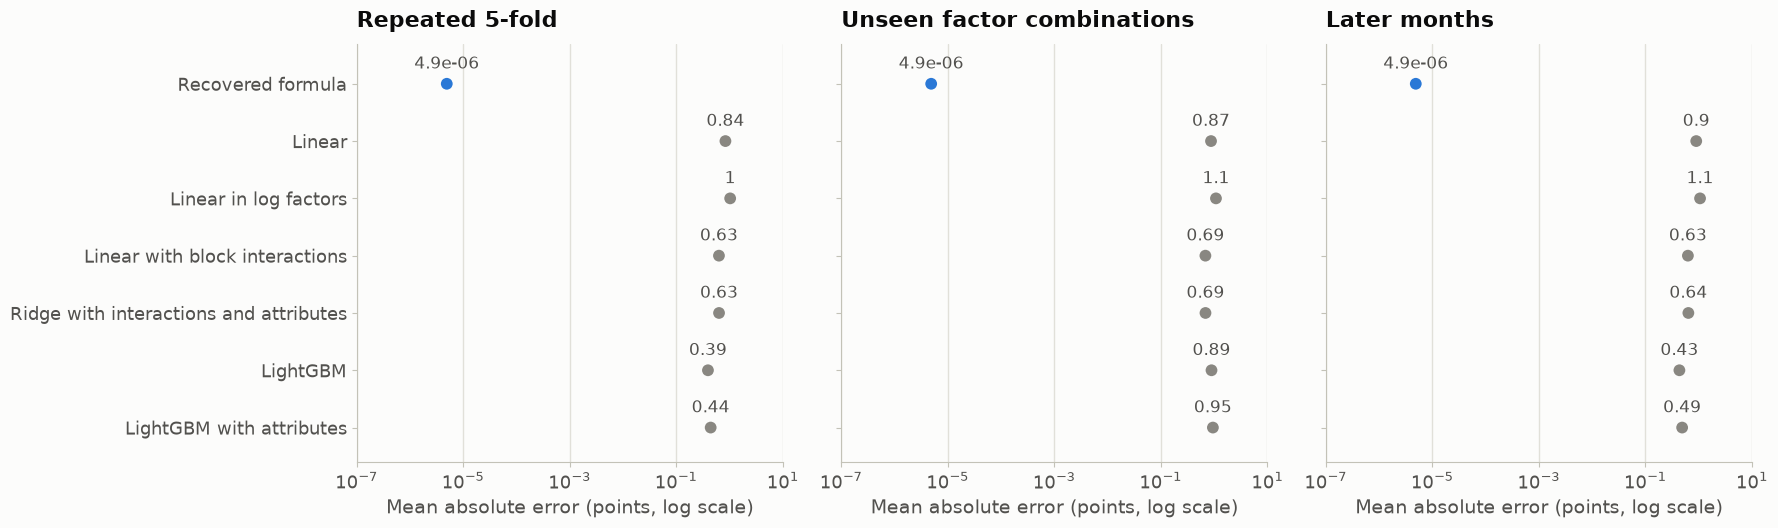

In [9]:
validation = pd.concat(
    [
        cv_summary[["candidate", "mae_mean"]].assign(scheme="Repeated 5-fold"),
        grouped_summary[["candidate", "mae_mean"]].assign(
            scheme="Unseen factor combinations"
        ),
        temporal[["candidate", "mae"]]
        .rename(columns={"mae": "mae_mean"})
        .assign(scheme="Later months"),
    ]
)
names = list(candidates)
positions = np.arange(len(names))
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, (scheme, rows) in zip(axes, validation.groupby("scheme", sort=False)):
    values = rows.set_index("candidate").loc[names, "mae_mean"].to_numpy()
    colors = [BLUE if name == FORMULA else MUTED for name in names]
    ax.scatter(
        values, positions, s=110, color=colors, edgecolor=SURFACE, linewidth=2, zorder=2
    )
    for y, value in zip(positions, values):
        ax.annotate(
            f"{value:.2g}",
            (value, y),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=12,
            color=INK_SECONDARY,
        )
    ax.set_xscale("log")
    ax.set_xlim(1e-7, 10)
    ax.set(title=scheme, xlabel="Mean absolute error (points, log scale)")
    ax.grid(axis="x")
    ax.grid(visible=False, axis="y")
axes[0].set_yticks(positions, names)
axes[0].set_ylim(len(names) - 0.4, -0.7)
fig.tight_layout()
save_figure(fig, "score_model_validation")

## 6. Final evaluation on the held-out test set

Every candidate is fitted on the whole training set. The selection above was made
before this point; the other candidates are shown for comparison. Intervals are
percentile bootstrap 95% intervals over test households.

In [10]:
def same_category_share(recorded: np.ndarray, predicted: np.ndarray) -> float:
    """Share of households whose predicted category is the recorded one."""
    return float(np.mean(recorded == predicted))


test_predictions = {
    name: fit_predict(train, test) for name, fit_predict in candidates.items()
}
observed = test[TARGET].to_numpy()
code_of = {label: code for code, label in enumerate(category_labels)}
recorded_codes = test["Vulnerability_Category"].cat.codes.to_numpy()
metric_rows = []
for name, predicted in test_predictions.items():
    point = score_metrics(test, predicted)
    for metric, function in SCORE_METRICS.items():
        low, high = bootstrap_interval(function, observed, predicted, N_BOOTSTRAP, SEED)
        metric_rows.append(
            {
                "candidate": name,
                "metric": metric,
                "value": point[metric],
                "ci_low": low,
                "ci_high": high,
            }
        )
    predicted_codes = predicted_category(predicted, test.index).map(code_of).to_numpy()
    low, high = bootstrap_interval(
        same_category_share, recorded_codes, predicted_codes, N_BOOTSTRAP, SEED
    )
    metric_rows.append(
        {
            "candidate": name,
            "metric": "category_accuracy",
            "value": point["category_accuracy"],
            "ci_low": low,
            "ci_high": high,
        }
    )
test_metrics = save_table(pd.DataFrame(metric_rows), "score_model_test_metrics")
test_metrics.pivot(index="candidate", columns="metric", values="value").loc[names]

metric,category_accuracy,mae,max_abs_error,r2,rmse
candidate,,,,,
Recovered formula,0.994737,0.000005,0.000015,1.000000,0.000006
Linear,0.952632,0.884762,7.271668,0.992659,1.254840
Linear in log factors,0.918421,1.017968,6.819205,0.991620,1.340738
Linear with block interactions,0.928947,0.669918,3.356187,0.996470,0.870241
Ridge with interactions and attributes,0.926316,0.668710,3.392903,0.996483,0.868555
LightGBM,0.973684,0.299924,6.323657,0.998440,0.578447
LightGBM with attributes,0.968421,0.347280,6.542501,0.998089,0.640198


In [11]:
formula_category = predicted_category(test_predictions[FORMULA], test.index)
distance = np.abs(
    test_predictions[FORMULA][:, None] - np.asarray(final_cutpoints)[None, :]
)
near_cutpoint = distance.min(axis=1) < NEAR_CUTPOINT
change_rows = []
for name, predicted in test_predictions.items():
    changed = (predicted_category(predicted, test.index) != formula_category).to_numpy()
    change_rows.append(
        {
            "candidate": name,
            "test_households": len(test),
            "category_differs_from_formula": int(changed.sum()),
            "of_which_near_cutpoint": int((changed & near_cutpoint).sum()),
            "households_near_cutpoint": int(near_cutpoint.sum()),
        }
    )
category_changes = save_table(pd.DataFrame(change_rows), "score_model_category_changes")
category_changes

,candidate,test_households,category_differs_from_formula,of_which_near_cutpoint,households_near_cutpoint
0,Recovered formula,380,0,0,95
1,Linear,380,16,15,95
2,Linear in log factors,380,29,28,95
3,Linear with block interactions,380,25,25,95
4,Ridge with interactions and attributes,380,26,26,95
5,LightGBM,380,8,8,95
6,LightGBM with attributes,380,10,10,95


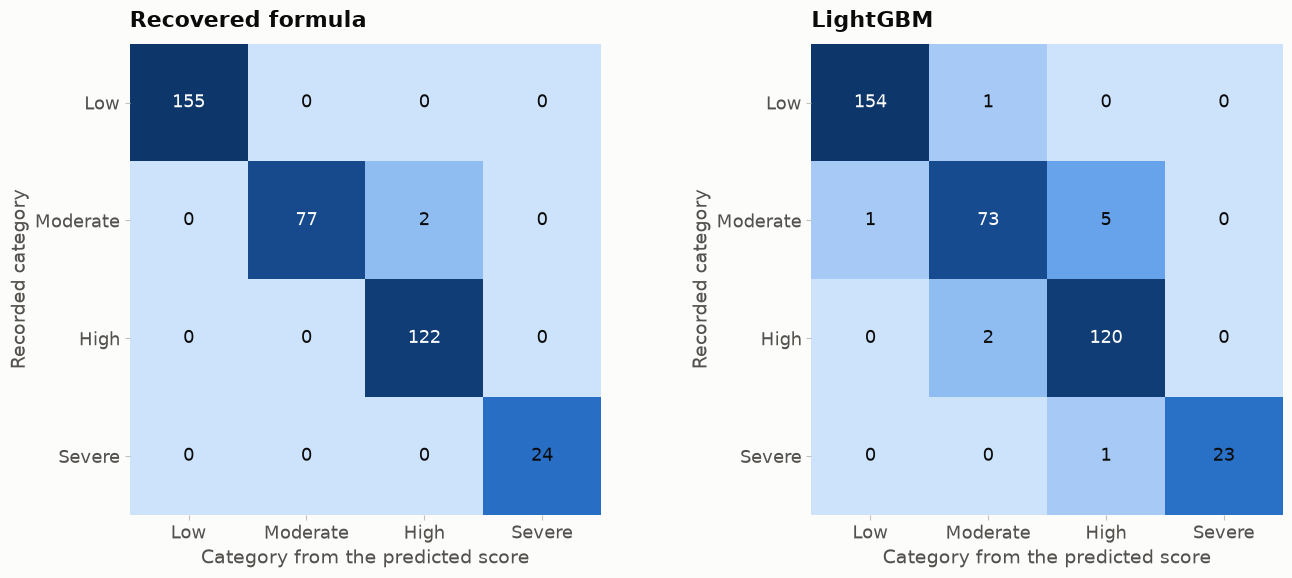

In [12]:
confusion_frames = []
for name in (selected, best_learned):
    predicted_labels = predicted_category(test_predictions[name], test.index)
    counts = (
        pd.crosstab(test["Vulnerability_Category"].astype(str), predicted_labels)
        .reindex(index=category_labels, columns=category_labels, fill_value=0)
        .rename_axis(index="recorded", columns="predicted")
    )
    confusion_frames.append(
        counts.stack().rename("households").reset_index().assign(model=name)
    )
confusion = pd.concat(confusion_frames, ignore_index=True)
save_table(
    confusion[["model", "recorded", "predicted", "households"]], "score_model_confusion"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, rows) in zip(axes, confusion.groupby("model", sort=False)):
    matrix = rows.pivot(index="recorded", columns="predicted", values="households")
    matrix = matrix.loc[category_labels, category_labels].to_numpy()
    ax.imshow(np.log1p(matrix), cmap=SEQUENTIAL)
    for row, col in np.ndindex(matrix.shape):
        ax.text(
            col,
            row,
            f"{matrix[row, col]:,}",
            ha="center",
            va="center",
            fontsize=13,
            color=SURFACE if matrix[row, col] > 40 else INK,
        )
    ax.set_xticks(range(4), category_labels)
    ax.set_yticks(range(4), category_labels)
    ax.set(
        title=name,
        xlabel="Category from the predicted score",
        ylabel="Recorded category",
    )
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.tight_layout()
save_figure(fig, "score_model_confusion")

In [13]:
size_group = (
    test["NumIntegrantes"]
    .clip(upper=5)
    .map(lambda size: "5 or more" if size == 5 else str(size))
)
subgroup_frames = []
for name in (selected, best_learned):
    predicted = test_predictions[name]
    frame = pd.DataFrame(
        {
            "error": np.abs(observed - predicted),
            "same_category": predicted_category(predicted, test.index).to_numpy()
            == test["Vulnerability_Category"].astype(str).to_numpy(),
            "Household size": size_group.to_numpy(),
            "Recorded category": test["Vulnerability_Category"].to_numpy(),
            "UNHCR field office": test["OficinaACNUR"].to_numpy(),
        }
    )
    for breakdown in ["Household size", "Recorded category", "UNHCR field office"]:
        summary = (
            frame.groupby(breakdown, observed=True)
            .agg(
                n=("error", "size"),
                mae=("error", "mean"),
                max_abs_error=("error", "max"),
                category_accuracy=("same_category", "mean"),
            )
            .reset_index(names="group")
        )
        subgroup_frames.append(summary.assign(model=name, breakdown=breakdown))
subgroups = pd.concat(subgroup_frames, ignore_index=True)
subgroups["small_group"] = subgroups["n"] < SMALL_GROUP_N
subgroups = subgroups[
    [
        "model",
        "breakdown",
        "group",
        "n",
        "mae",
        "max_abs_error",
        "category_accuracy",
        "small_group",
    ]
]
save_table(subgroups, "score_model_test_subgroups")
subgroups[subgroups["model"] == best_learned]

,model,breakdown,group,n,mae,max_abs_error,category_accuracy,small_group
17,LightGBM,Household size,1,178,0.298755,2.942631,0.971910,False
18,LightGBM,Household size,2,60,0.336328,1.515974,0.983333,False
19,LightGBM,Household size,3,69,0.368094,6.323657,0.956522,False
20,LightGBM,Household size,4,42,0.266542,1.723915,0.976190,False
21,LightGBM,Household size,5 or more,31,0.129674,0.568561,1.000000,False
22,LightGBM,Recorded category,High,122,0.321630,2.822969,0.983607,False
23,LightGBM,Recorded category,Low,155,0.222047,1.444333,0.993548,False
24,LightGBM,Recorded category,Moderate,79,0.321162,6.323657,0.924051,False
25,LightGBM,Recorded category,Severe,24,0.622631,2.942631,0.958333,True
26,LightGBM,UNHCR field office,Blank,3,0.500737,1.407698,0.666667,True


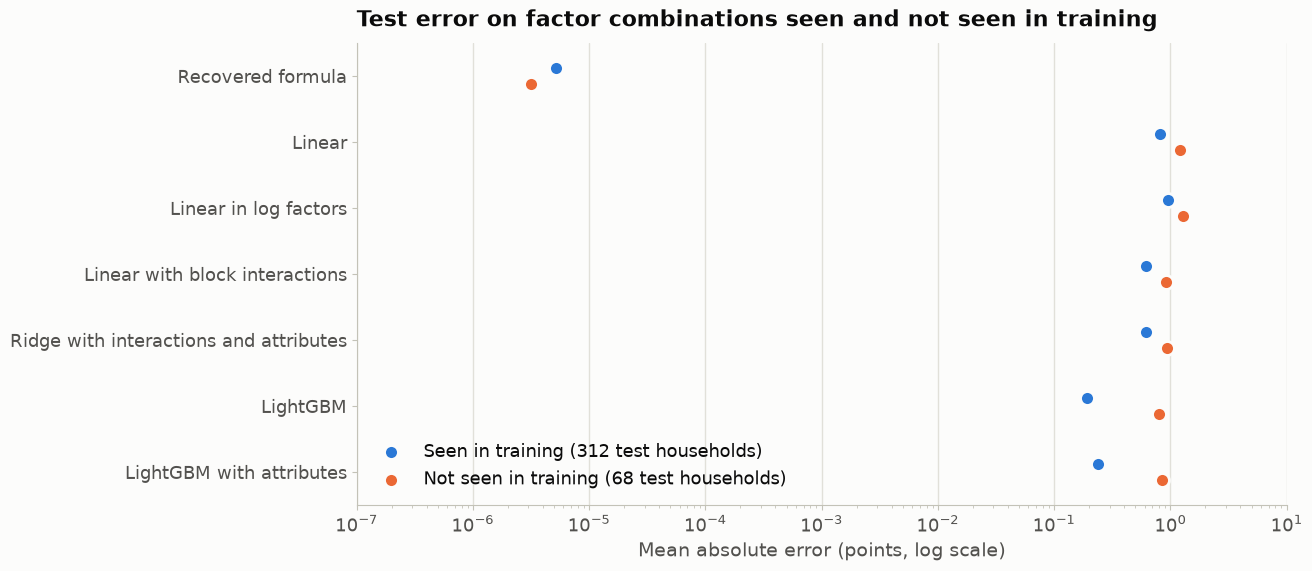

In [14]:
train_combinations = set(map(tuple, train[FACTORS].to_numpy()))
seen = np.array([tuple(row) in train_combinations for row in test[FACTORS].to_numpy()])
seen_rows = []
for name, predicted in test_predictions.items():
    for status, mask in [("Seen in training", seen), ("Not seen in training", ~seen)]:
        error = np.abs(observed[mask] - predicted[mask])
        seen_rows.append(
            {
                "candidate": name,
                "combination": status,
                "households": int(mask.sum()),
                "mae": error.mean(),
                "max_abs_error": error.max(),
            }
        )
unseen = save_table(pd.DataFrame(seen_rows), "score_model_unseen_combinations")

fig, ax = plt.subplots(figsize=(12, 6))
for offset, (status, color) in zip(
    (-0.12, 0.12), [("Seen in training", BLUE), ("Not seen in training", ORANGE)]
):
    values = (
        unseen[unseen["combination"] == status].set_index("candidate").loc[names, "mae"]
    )
    count = unseen[unseen["combination"] == status]["households"].iloc[0]
    ax.scatter(
        values,
        positions + offset,
        s=100,
        color=color,
        edgecolor=SURFACE,
        linewidth=2,
        zorder=2,
        label=f"{status} ({count} test households)",
    )
ax.set_xscale("log")
ax.set_xlim(1e-7, 10)
ax.set_yticks(positions, names)
ax.set_ylim(len(names) - 0.5, -0.5)
ax.set(
    title="Test error on factor combinations seen and not seen in training",
    xlabel="Mean absolute error (points, log scale)",
)
ax.grid(axis="x")
ax.grid(visible=False, axis="y")
ax.legend(loc="lower left")
save_figure(fig, "score_model_unseen_combinations")

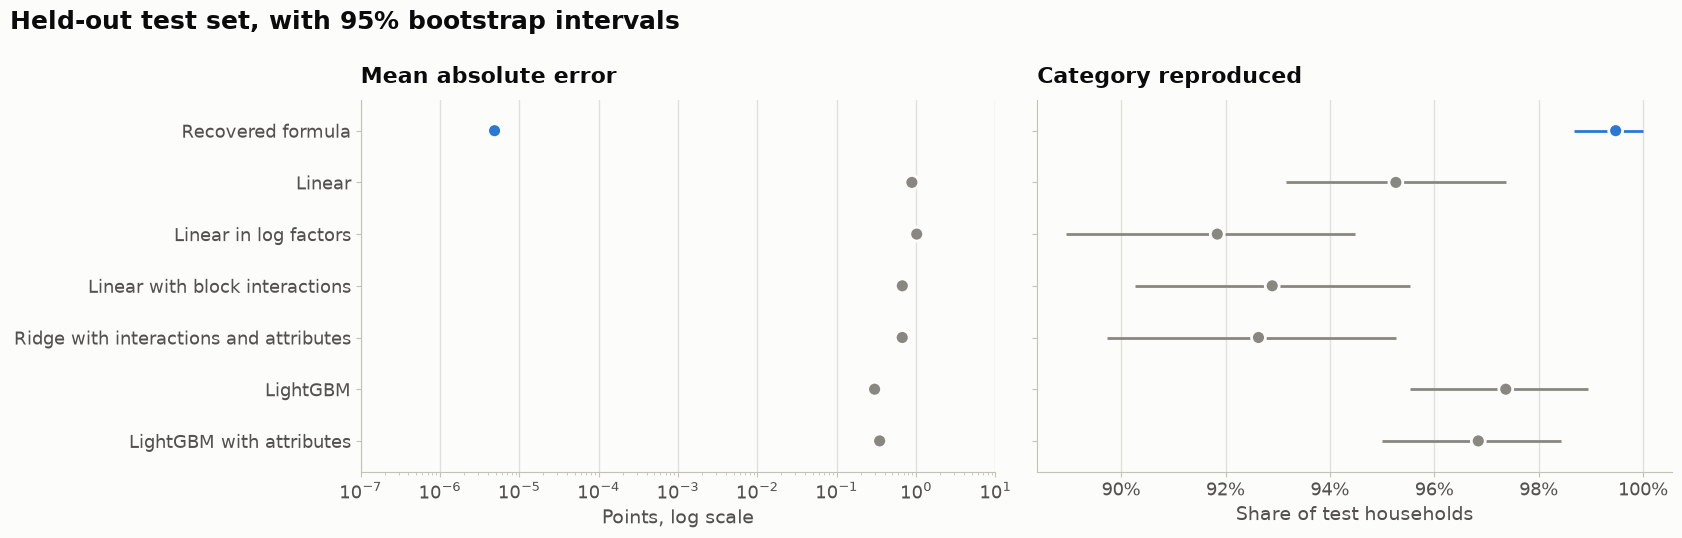

In [15]:
fig, (left, right) = plt.subplots(1, 2, figsize=(17, 5.5), sharey=True)
for ax, metric, scale in [(left, "mae", "log"), (right, "category_accuracy", "linear")]:
    rows = (
        test_metrics[test_metrics["metric"] == metric].set_index("candidate").loc[names]
    )
    colors = [BLUE if name == FORMULA else MUTED for name in names]
    ax.hlines(
        positions, rows["ci_low"], rows["ci_high"], color=colors, linewidth=2, zorder=1
    )
    ax.scatter(
        rows["value"],
        positions,
        s=100,
        color=colors,
        edgecolor=SURFACE,
        linewidth=2,
        zorder=2,
    )
    ax.set_xscale(scale)
    ax.grid(axis="x")
    ax.grid(visible=False, axis="y")
left.set(title="Mean absolute error", xlabel="Points, log scale")
left.set_xlim(1e-7, 10)
right.set(title="Category reproduced", xlabel="Share of test households")
right.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
left.set_yticks(positions, names)
left.set_ylim(len(names) - 0.4, -0.6)
fig.suptitle("Held-out test set, with 95% bootstrap intervals", x=0.01, ha="left")
fig.tight_layout()
save_figure(fig, "score_model_test_metrics")

## 7. Attributions for the Answer panel

Exact Shapley values of the formula for every household: each factor's share of the
final score, measured from the household with every factor at 1.0, which scores 0.

In [16]:
shapley = scorecard.shapley_values(data)
formula_all = scorecard.final_score(data)
shapley_checks = pd.DataFrame(
    [
        ("Households", len(data)),
        (
            "Largest absolute difference, sum of attributions vs formula score",
            (shapley.sum(axis=1) - formula_all).abs().max(),
        ),
        (
            "Largest absolute difference, sum of attributions vs recorded final score",
            (shapley.sum(axis=1) - data[TARGET]).abs().max(),
        ),
        ("Smallest attribution (points)", shapley.min().min()),
    ],
    columns=["statistic", "value"],
)
save_table(shapley_checks, "shapley_checks")

,statistic,value
0,Households,1.900000e+03
1,"Largest absolute difference, sum of attributio...",2.842171e-14
2,"Largest absolute difference, sum of attributio...",1.543926e-05
3,Smallest attribution (points),0.000000e+00


In [17]:
largest = shapley.idxmax(axis=1)[formula_all > 0]
shapley_summary = pd.DataFrame(
    {
        "factor": factor_names,
        "block": [
            "Demographics" if column in DEMOGRAPHIC_FACTORS else "Needs and coping"
            for column in FACTORS
        ],
        "mean_attribution": shapley.mean().to_numpy(),
        "share_of_mean_score": (shapley.mean() / formula_all.mean()).to_numpy(),
        "households_where_largest": largest.value_counts()
        .reindex(FACTORS, fill_value=0)
        .to_numpy(),
    }
).sort_values("mean_attribution", ascending=False)
save_table(shapley_summary, "shapley_summary")
shapley_summary

,factor,block,mean_attribution,share_of_mean_score,households_where_largest
5,Housing,Needs and coping,7.030109,0.253405,824
6,Negative coping,Needs and coping,6.805034,0.245292,433
4,Basic needs,Needs and coping,4.766337,0.171806,28
2,Specific needs,Demographics,3.969005,0.143066,343
0,Head of household,Demographics,3.035824,0.109429,169
1,Language barrier,Demographics,1.171286,0.042220,32
7,Dependency,Needs and coping,0.808953,0.029159,15
3,Documentation,Demographics,0.155984,0.005623,6


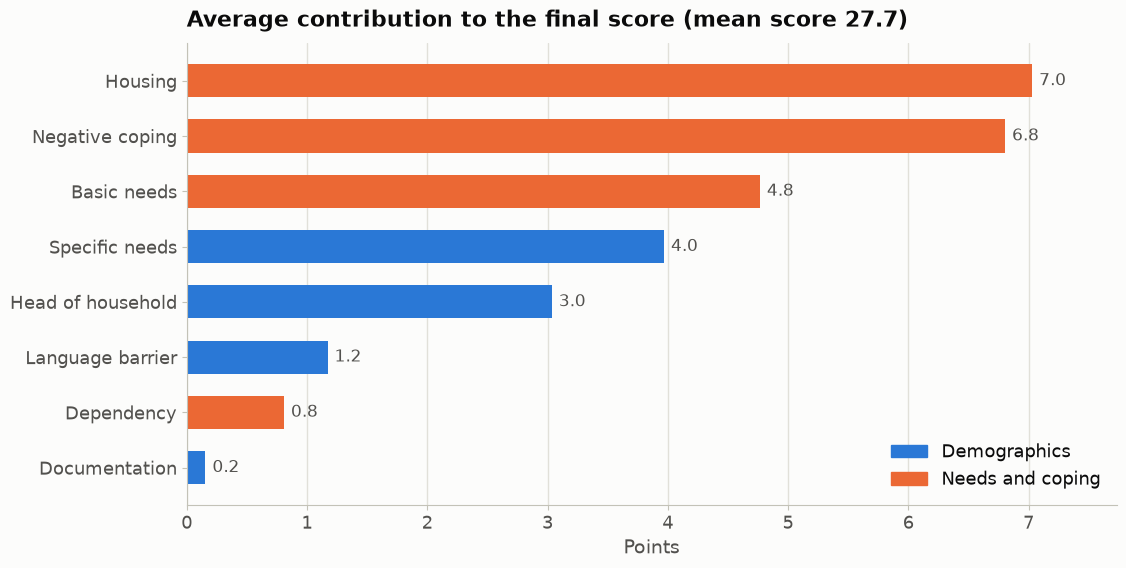

In [18]:
positions_factor = np.arange(len(shapley_summary))
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    positions_factor,
    shapley_summary["mean_attribution"],
    height=0.6,
    color=[
        BLUE if block == "Demographics" else ORANGE
        for block in shapley_summary["block"]
    ],
)
for y, value in zip(positions_factor, shapley_summary["mean_attribution"]):
    ax.annotate(
        f"{value:.1f}",
        (value, y),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=12,
        color=INK_SECONDARY,
    )
ax.set_yticks(positions_factor, shapley_summary["factor"])
ax.invert_yaxis()
ax.margins(x=0.1)
ax.set(
    title=f"Average contribution to the final score (mean score {formula_all.mean():.1f})",
    xlabel="Points",
)
ax.grid(axis="x")
ax.grid(visible=False, axis="y")
ax.legend(
    handles=[
        Patch(color=BLUE, label="Demographics"),
        Patch(color=ORANGE, label="Needs and coping"),
    ],
    loc="lower right",
)
save_figure(fig, "shapley_mean_by_factor")

For comparison, SHAP values of the LightGBM model fitted on the training set,
measured from the same reference household (every factor at 1.0).

In [19]:
lightgbm_model = make_lightgbm().fit(factor_features(train), train[TARGET])
reference = pd.DataFrame([dict.fromkeys(FACTORS, 1.0)])
explainer = shap.TreeExplainer(
    lightgbm_model, data=reference, feature_perturbation="interventional"
)
lightgbm_shap = pd.DataFrame(
    explainer.shap_values(factor_features(test)), index=test.index, columns=FACTORS
)
formula_shap = shapley.loc[test.index]
difference = (lightgbm_shap - formula_shap).abs()
shap_comparison = pd.DataFrame(
    {
        "factor": factor_names,
        "formula_mean_attribution": formula_shap.mean().to_numpy(),
        "lightgbm_mean_attribution": lightgbm_shap.mean().to_numpy(),
        "mean_absolute_difference": difference.mean().to_numpy(),
        "largest_absolute_difference": difference.max().to_numpy(),
    }
)
save_table(shap_comparison, "shap_lightgbm_vs_formula")
scored = formula_shap.sum(axis=1) > 0
shap_summary = pd.DataFrame(
    [
        ("Test households", len(test)),
        (
            "LightGBM prediction for the reference household (every factor at 1.0)",
            float(lightgbm_model.predict(reference)[0]),
        ),
        (
            "Mean over households of the summed absolute attribution difference",
            difference.sum(axis=1).mean(),
        ),
        (
            "Share of scoring households whose largest factor differs",
            (
                lightgbm_shap[scored].idxmax(axis=1)
                != formula_shap[scored].idxmax(axis=1)
            ).mean(),
        ),
    ],
    columns=["statistic", "value"],
)
save_table(shap_summary, "shap_lightgbm_vs_formula_summary")
shap_summary

,statistic,value
0,Test households,380.000000
1,LightGBM prediction for the reference househol...,0.039720
2,Mean over households of the summed absolute at...,1.272487
3,Share of scoring households whose largest fact...,0.067385


In [20]:
linear_model = LinearRegression().fit(factor_features(train), train[TARGET])
coefficients = pd.DataFrame(
    {
        "term": ["Intercept", *factor_names],
        "coefficient": [linear_model.intercept_, *linear_model.coef_],
    }
)
save_table(coefficients, "linear_coefficients")

,term,coefficient
0,Intercept,-63.767856
1,Head of household,6.893127
2,Language barrier,8.071160
3,Specific needs,6.305775
4,Documentation,8.695106
5,Basic needs,8.331086
6,Housing,7.514454
7,Negative coping,7.389657
8,Dependency,9.849257


Three test households, chosen by final score, as the Answer panel would show them.

In [21]:
formula_test = pd.Series(test_predictions[FORMULA], index=test.index)
lightgbm_test = pd.Series(test_predictions["LightGBM"], index=test.index)
examples = {
    f"Household {label}": (formula_test - target).abs().idxmin()
    for label, target in zip("ABC", EXAMPLE_SCORES)
}
example_rows, example_scores = [], []
for example, household in examples.items():
    result = predict(data.loc[household, FACTORS].to_dict())
    example_scores.append(
        {
            "example": example,
            "score": result["score"],
            "category": result["category"],
            "recorded_score": data.at[household, TARGET],
            "recorded_category": data.at[household, "Vulnerability_Category"],
            "lightgbm_score": lightgbm_test[household],
            "lightgbm_category": predicted_category(
                np.array([lightgbm_test[household]]), pd.Index([household])
            ).iloc[0],
        }
    )
    for column in FACTORS:
        example_rows.append(
            {
                "example": example,
                "factor": ENGLISH_NAMES[column],
                "level": data.at[household, column],
                "formula_attribution": result["attributions"][column],
                "lightgbm_attribution": lightgbm_shap.at[household, column],
            }
        )
example_scores = save_table(pd.DataFrame(example_scores), "answer_panel_example_scores")
example_attributions = save_table(pd.DataFrame(example_rows), "answer_panel_examples")
example_scores

,example,score,category,recorded_score,recorded_category,lightgbm_score,lightgbm_category
0,Household A,15.131550,Low,15.131551,Low,15.060767,Low
1,Household B,30.957751,Moderate,30.957746,Moderate,31.272241,High
2,Household C,60.657526,Severe,60.657517,Severe,60.586396,Severe


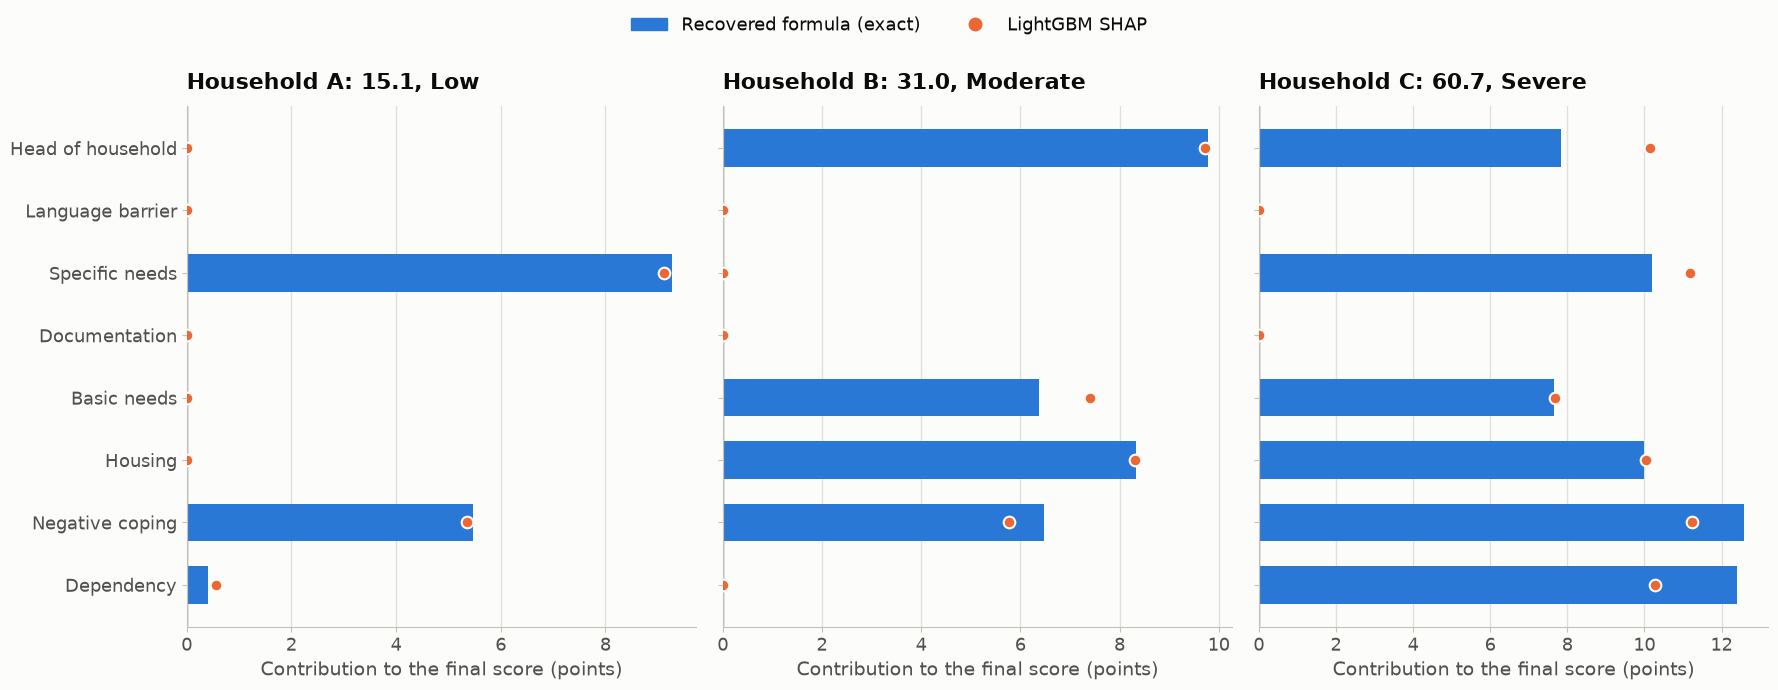

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)
y = np.arange(len(FACTORS))
for ax, (example, rows) in zip(
    axes, example_attributions.groupby("example", sort=False)
):
    summary = example_scores.set_index("example").loc[example]
    ax.barh(y, rows["formula_attribution"], height=0.6, color=BLUE)
    ax.scatter(
        rows["lightgbm_attribution"],
        y,
        s=70,
        color=ORANGE,
        edgecolor=SURFACE,
        linewidth=1.5,
        zorder=3,
    )
    ax.axvline(0, color=MUTED, linewidth=1)
    ax.set(
        title=f"{example}: {summary['score']:.1f}, {summary['category']}",
        xlabel="Contribution to the final score (points)",
    )
    ax.grid(axis="x")
    ax.grid(visible=False, axis="y")
axes[0].set_yticks(y, factor_names)
axes[0].invert_yaxis()
fig.legend(
    handles=[
        Patch(color=BLUE, label="Recovered formula (exact)"),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=9,
            color=ORANGE,
            label="LightGBM SHAP",
        ),
    ],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.0),
)
fig.tight_layout()
save_figure(fig, "answer_panel_examples")

`predict` applied to every household of the sample.

In [23]:
predictions = [predict(row) for row in data[FACTORS].to_dict("records")]
predicted_scores = np.array([result["score"] for result in predictions])
predicted_categories = np.array([result["category"] for result in predictions])
attribution_sums = np.array(
    [sum(result["attributions"].values()) for result in predictions]
)
predict_checks = pd.DataFrame(
    [
        ("Households", len(data)),
        (
            "Largest absolute difference from the recorded final score",
            np.abs(predicted_scores - data[TARGET].to_numpy()).max(),
        ),
        (
            "Households whose category matches the recorded one",
            int(
                (
                    predicted_categories == data["Vulnerability_Category"].astype(str)
                ).sum()
            ),
        ),
        (
            "Largest absolute difference, sum of attributions vs score",
            np.abs(attribution_sums - predicted_scores).max(),
        ),
    ],
    columns=["statistic", "value"],
)
save_table(predict_checks, "predict_checks")

,statistic,value
0,Households,1.900000e+03
1,Largest absolute difference from the recorded ...,1.543926e-05
2,Households whose category matches the recorded...,1.890000e+03
3,"Largest absolute difference, sum of attributio...",2.131628e-14


In [24]:
metric_value = test_metrics.set_index(["candidate", "metric"])
changes = category_changes.set_index("candidate")
unseen_mae = unseen.set_index(["candidate", "combination"])["mae"]


def metric_with_interval(name: str, metric: str) -> dict:
    """Point estimate and 95% interval of one test metric."""
    row = metric_value.loc[(name, metric)]
    return {
        "value": float(row["value"]),
        "ci": [float(row["ci_low"]), float(row["ci_high"])],
    }


update_key_stats(
    "phase_2_score_model",
    {
        "selected_model": selected,
        "selected_model_fitted_parameters": 0,
        "most_accurate_learned_model": best_learned,
        "test_households": len(test),
        "formula_test_mae": metric_with_interval(FORMULA, "mae"),
        "formula_test_max_abs_error": metric_with_interval(FORMULA, "max_abs_error"),
        "formula_test_category_accuracy": metric_with_interval(
            FORMULA, "category_accuracy"
        ),
        "best_learned_test_mae": metric_with_interval(best_learned, "mae"),
        "best_learned_test_max_abs_error": metric_with_interval(
            best_learned, "max_abs_error"
        ),
        "best_learned_test_category_accuracy": metric_with_interval(
            best_learned, "category_accuracy"
        ),
        "best_learned_category_differs_from_formula": int(
            changes.loc[best_learned, "category_differs_from_formula"]
        ),
        "best_learned_unseen_combination_mae": float(
            unseen_mae[(best_learned, "Not seen in training")]
        ),
        "attribution_sum_max_abs_error": float(shapley_checks["value"].iloc[1]),
        "largest_mean_attribution_factor": shapley_summary["factor"].iloc[0],
        "lightgbm_shap_mean_total_difference": float(shap_summary["value"].iloc[2]),
        "lightgbm_largest_factor_differs_share": float(shap_summary["value"].iloc[3]),
    },
)